## Data loading

In [2]:

import numpy as np
import pickle
import sys
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
mpl.style.use(['ggplot'])
%matplotlib inline
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline

In [4]:
from sklearn.datasets import make_circles
X, y = make_circles(1000, factor=.1, noise=.2, random_state=336546)

In [5]:
X_train, x_test, Y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 10, stratify=y)

In [31]:
def plot_radar(clf, clf_type):
    labels=np.array(['Accuracy', 'F1', 'PPV', 'Sensitivity', 'AUROC'])
    score_mat_train = np.stack((clf.cv_results_['mean_train_accuracy'], clf.cv_results_['mean_train_f1'],
                               clf.cv_results_['mean_train_precision'], clf.cv_results_['mean_train_recall'],
                               clf.cv_results_['mean_train_roc_auc']), axis=0)
    score_mat_val = np.stack((clf.cv_results_['mean_test_accuracy'], clf.cv_results_['mean_test_f1'],
                               clf.cv_results_['mean_test_precision'], clf.cv_results_['mean_test_recall'],
                               clf.cv_results_['mean_test_roc_auc']), axis=0)


    angles=np.linspace(0, 2*np.pi, len(labels), endpoint=False)

    angles=np.concatenate((angles,[angles[0]]))
    cv_dict = clf.cv_results_['params']
    fig=plt.figure(figsize=(18,14))

    kernel_type = clf_type[0]
    new_list = []
    xlabel_text = ""

    if kernel_type == 'linear':
        new_list = [(i, item) for i, item in enumerate(cv_dict) if item.get("svm__kernel") == 'linear']
    elif kernel_type == 'rbf':
        gamma_value = clf_type[1]
        new_list = [(i, item) for i, item in enumerate(cv_dict) if
                    item.get("svm__kernel") == 'rbf' and item.get("svm__gamma") == gamma_value]
        xlabel_text = r'$\gamma = %s $' % gamma_value
    elif kernel_type == 'poly':
        degree_value = clf_type[1][0]
        coef0_value = clf_type[1][1]
        new_list = [(i, item) for i, item in enumerate(cv_dict) if
                    item.get("svm__kernel") == 'poly' and item.get("svm__degree") == degree_value and item.get("svm__coef0") == coef0_value]
        xlabel_text = f'degree={degree_value}, coef0={coef0_value}'

    if not new_list:
        print(f"No matching parameters found for kernel_type: {kernel_type}, clf_type: {clf_type}")
        plt.close(fig)
        return

    for idx, val in enumerate(new_list):
        ax = fig.add_subplot(1, len(new_list), 1+idx, polar=True)
        rel_idx, rel_dict = val
        stats_train = score_mat_train[:, rel_idx]
        stats_train=np.concatenate((stats_train,[stats_train[0]]))
        ax.plot(angles, stats_train, 'o-', linewidth=2, label='Train')
        ax.fill(angles, stats_train, alpha=0.25)
        stats_val = score_mat_val[:, rel_idx]
        stats_val=np.concatenate((stats_val,[stats_val[0]]))
        ax.plot(angles, stats_val, 'o-', linewidth=2, label='Validation')
        ax.fill(angles, stats_val, alpha=0.25)
        ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
        if idx == 0:
            ax.set_ylabel(kernel_type, fontsize=18)
        ax.set_title(f'C = {rel_dict["svm__C"]:.3f}')
        if xlabel_text:
            ax.set_xlabel(xlabel_text)
        ax.set_ylim([0,1])
        ax.legend(['Train','Validation'], loc='upper right', bbox_to_anchor=(1.3, 1.1))
        ax.grid(True)

    plt.tight_layout()
    plt.show()

In [7]:
def plot_dataset(x_train, x_test, y_train, y_test, axes_range):
    fig, axs = plt.subplots(1, 2, figsize=(12,6))
    for idx, ax in enumerate(axs.flatten()):
        if idx == 0:
            ax.plot(x_train[:, 0][y_train==0], x_train[:, 1][y_train==0], "bs")
            ax.plot(x_train[:, 0][y_train==1], x_train[:, 1][y_train==1], "g^")
            ax.set_title('Train')
        else:
            ax.plot(x_test[:, 0][y_test==0], x_test[:, 1][y_test==0], "bs")
            ax.plot(x_test[:, 0][y_test==1], x_test[:, 1][y_test==1], "g^")
            ax.set_title('Test')
        ax.axis(axes_range)
        ax.grid(True, which='both')
        ax.set_xlabel(r"$x_1$", fontsize=20)
        ax.set_ylabel(r"$x_2$", fontsize=20, rotation=0)
    return fig, axs

In [8]:
def plot_predictions(clf, axs, axes_range):
    x0s = np.linspace(axes_range[0], axes_range[1], 100)
    x1s = np.linspace(axes_range[2], axes_range[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    for idx, ax in enumerate(axs.flatten()):
        ax.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
        ax.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)
        if idx == 0:
            ax.set_title('Train')
        else:
            ax.set_title('Test')

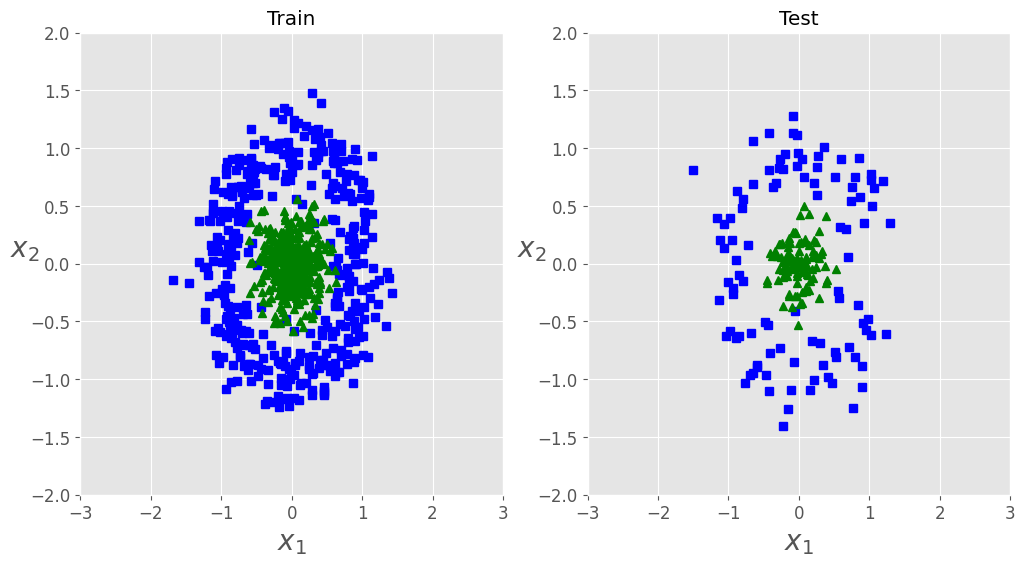

In [9]:
axes_range = [-3, 3, -2, 2]
_, _ = plot_dataset(X_train, x_test, Y_train, y_test, axes_range)

In [10]:
n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, random_state=10, shuffle=True)

In [14]:
#C1
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
svc = SVC(probability=True, random_state=336546)
C = np.array([0.001, 0.01, 1, 10, 100, 1000])
#--------------------------Impelment your code here:-------------------------------------
param_grid_lin = [
    {'svm__kernel': ['linear'], 'svm__C': C}
]
#------------------------------------------------------------------------------------------

In [15]:
#C2
#--------------------------Impelment your code here:-------------------------------------
scoring = {'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', 'roc_auc': 'roc_auc'}
pipeline_lin = Pipeline(steps=[('scale', StandardScaler()), ('svm', svc)])
svm_lin = GridSearchCV(pipeline_lin, param_grid_lin, cv=skf, scoring=scoring, refit='f1', verbose=3, return_train_score=True)
svm_lin.fit(X_train, Y_train)
best_svm_lin = svm_lin.best_estimator_
#-----------------------------------------------------------------------------------------

Fitting 3 folds for each of 6 candidates, totalling 18 fits


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV 1/3] END svm__C=0.001, svm__kernel=linear; accuracy: (train=0.501, test=0.498) f1: (train=0.000, test=0.000) precision: (train=0.000, test=0.000) recall: (train=0.000, test=0.000) roc_auc: (train=0.525, test=0.439) total time=   0.3s
[CV 2/3] END svm__C=0.001, svm__kernel=linear; accuracy: (train=0.501, test=0.498) f1: (train=0.667, test=0.665) precision: (train=0.501, test=0.498) recall: (train=1.000, test=1.000) roc_auc: (train=0.515, test=0.485) total time=   0.3s
[CV 3/3] END svm__C=0.001, svm__kernel=linear; accuracy: (train=0.674, test=0.677) f1: (train=0.746, test=0.750) precision: (train=0.612, test=0.611) recall: (train=0.955, test=0.970) roc_auc: (train=0.517, test=0.479) total time=   0.2s


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV 1/3] END svm__C=0.01, svm__kernel=linear; accuracy: (train=0.501, test=0.494) f1: (train=0.000, test=0.000) precision: (train=0.000, test=0.000) recall: (train=0.000, test=0.000) roc_auc: (train=0.526, test=0.439) total time=   0.1s
[CV 2/3] END svm__C=0.01, svm__kernel=linear; accuracy: (train=0.501, test=0.498) f1: (train=0.667, test=0.665) precision: (train=0.501, test=0.498) recall: (train=1.000, test=1.000) roc_auc: (train=0.515, test=0.485) total time=   0.2s
[CV 3/3] END svm__C=0.01, svm__kernel=linear; accuracy: (train=0.674, test=0.677) f1: (train=0.746, test=0.750) precision: (train=0.612, test=0.611) recall: (train=0.955, test=0.970) roc_auc: (train=0.517, test=0.479) total time=   0.1s
[CV 1/3] END svm__C=1.0, svm__kernel=linear; accuracy: (train=0.675, test=0.610) f1: (train=0.745, test=0.706) precision: (train=0.613, test=0.568) recall: (train=0.951, test=0.933) roc_auc: (train=0.524, test=0.440) total time=   0.1s
[CV 2/3] END svm__C=1.0, svm__kernel=linear; accuracy

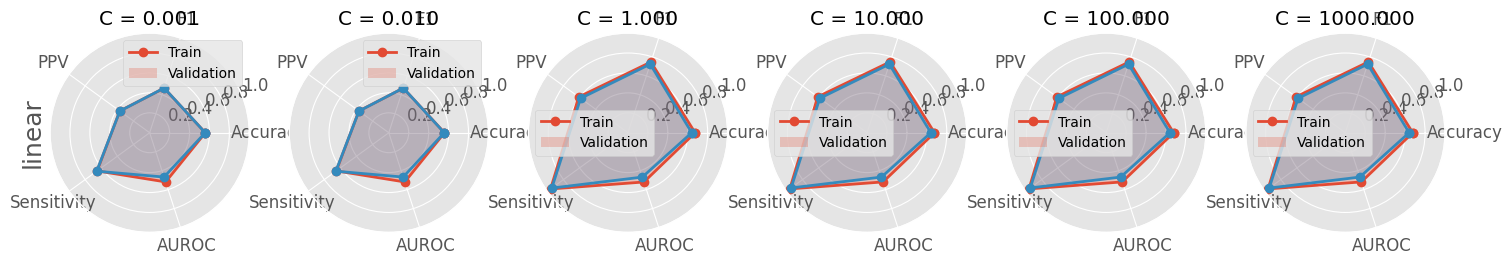

In [16]:
clf_type = ['linear']
plot_radar(svm_lin, clf_type)

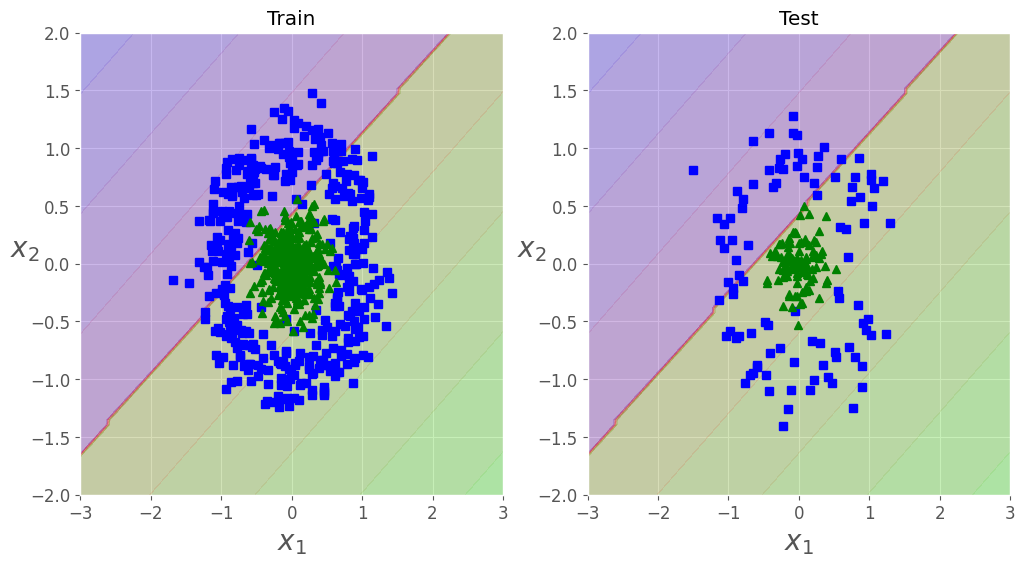

In [17]:
axes_range = [-3, 3, -2, 2]
_, axs = plot_dataset(X_train, x_test, Y_train, y_test, axes_range)
plot_predictions(best_svm_lin, axs, axes_range)

In [18]:
from sklearn.metrics import confusion_matrix
calc_TN = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[0, 0]
calc_FP = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[0, 1]
calc_FN = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[1, 0]
calc_TP = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[1, 1]

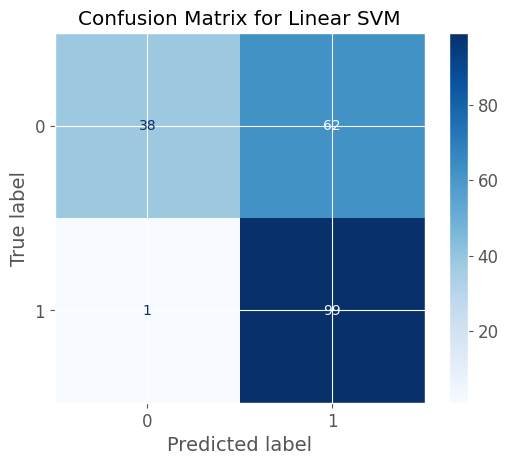

AUROC is 0.509


In [20]:
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay

y_pred_test = best_svm_lin.predict(x_test)
y_pred_proba_test = best_svm_lin.predict_proba(x_test)

# Display the confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(best_svm_lin, x_test, y_test, cmap=plt.cm.Blues, values_format='d')
disp.ax_.set_title('Confusion Matrix for Linear SVM')
plt.show()

print('AUROC is {:.3f}'.format(roc_auc_score(y_test, y_pred_proba_test[:,1])))

In [26]:
#C4
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
svc = SVC(probability=True, random_state=336546)
C = np.array([1, 100, 1000])
#--------------------------Impelment your code here:-------------------------------------
param_grid_nonlin = [
    {'svm__kernel': ['rbf'], 'svm__C': C, 'svm__gamma': ['scale', 1, 10]},
    {'svm__kernel': ['poly'], 'svm__C': C, 'svm__degree': [2, 3], 'svm__coef0': [0, 1]}
]
#-----------------------------------------------------------------------------------------

In [27]:
#C5
#--------------------------Impelment your code here:-------------------------------------
scoring = {'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', 'roc_auc': 'roc_auc'}
pipeline_nonlin = Pipeline(steps=[('scale', StandardScaler()), ('svm', svc)])
svm_nonlin = GridSearchCV(pipeline_nonlin, param_grid_nonlin, cv=skf, scoring=scoring, refit='f1', verbose=3, return_train_score=True)
svm_nonlin.fit(X_train, Y_train)
best_svm_nonlin = svm_nonlin.best_estimator_
#------------------------------------------------------------------------------------------

Fitting 3 folds for each of 21 candidates, totalling 63 fits
[CV 1/3] END svm__C=1, svm__gamma=scale, svm__kernel=rbf; accuracy: (train=0.983, test=0.978) f1: (train=0.983, test=0.978) precision: (train=0.974, test=0.964) recall: (train=0.992, test=0.993) roc_auc: (train=0.999, test=0.997) total time=   0.1s
[CV 2/3] END svm__C=1, svm__gamma=scale, svm__kernel=rbf; accuracy: (train=0.976, test=0.978) f1: (train=0.976, test=0.977) precision: (train=0.970, test=0.985) recall: (train=0.981, test=0.970) roc_auc: (train=0.998, test=0.998) total time=   0.0s
[CV 3/3] END svm__C=1, svm__gamma=scale, svm__kernel=rbf; accuracy: (train=0.981, test=0.974) f1: (train=0.981, test=0.974) precision: (train=0.974, test=0.970) recall: (train=0.989, test=0.977) roc_auc: (train=0.999, test=0.997) total time=   0.0s
[CV 1/3] END svm__C=1, svm__gamma=1, svm__kernel=rbf; accuracy: (train=0.985, test=0.974) f1: (train=0.985, test=0.974) precision: (train=0.978, test=0.964) recall: (train=0.992, test=0.985) r

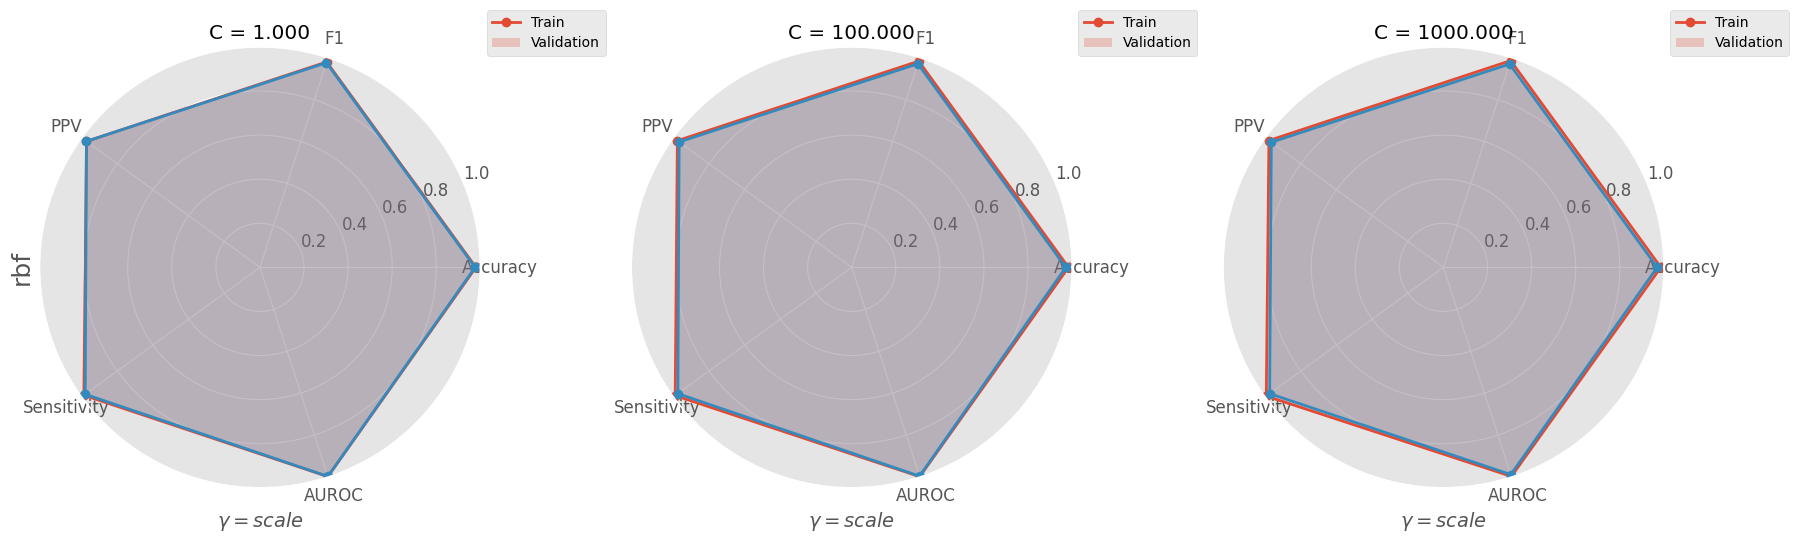

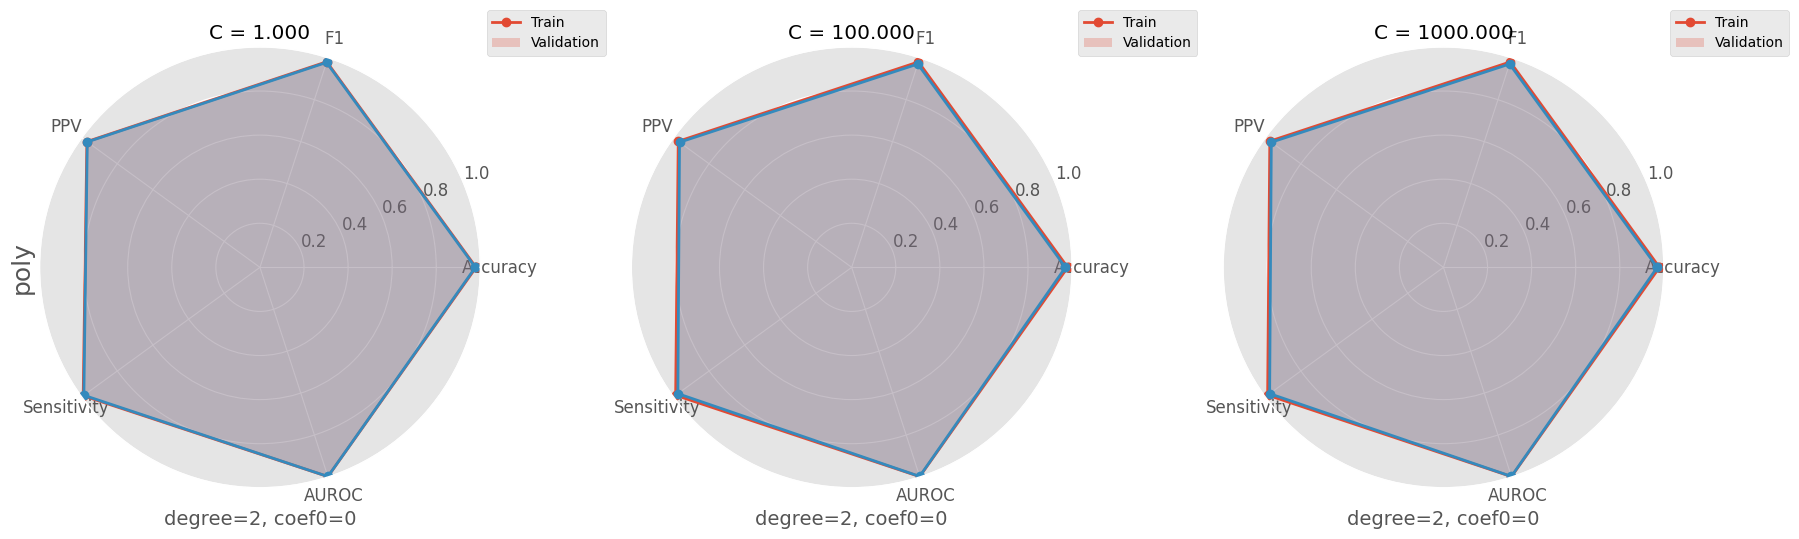

In [30]:
clf_type = ['rbf', 'scale']
plot_radar(svm_nonlin, clf_type)
clf_type = ['poly', [2, 0]]
plot_radar(svm_nonlin, clf_type)

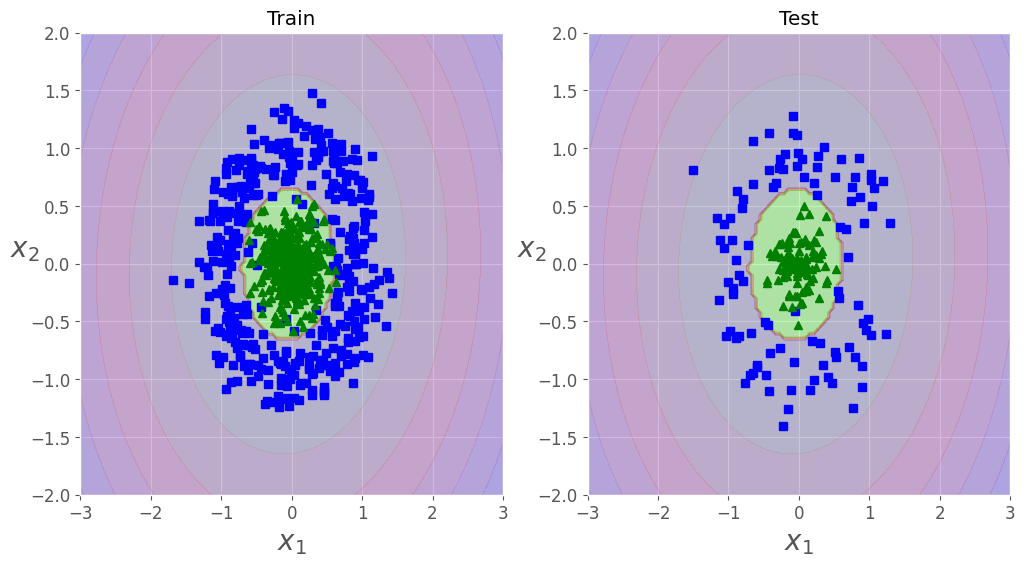

In [32]:
_, axs = plot_dataset(X_train, x_test, Y_train, y_test, axes_range)
plot_predictions(best_svm_nonlin, axs, axes_range)

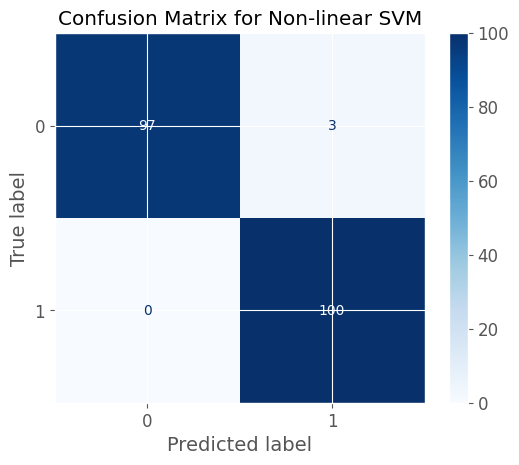

AUROC is 0.999


In [34]:
#C6
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_test = best_svm_nonlin.predict(x_test) #NOTICE NOT TO USE THE STANDARDIZED DATA.
y_pred_proba_test = best_svm_nonlin.predict_proba(x_test)
#--------------------------Impelment your code here:-------------------------------------
disp = ConfusionMatrixDisplay.from_estimator(best_svm_nonlin, x_test, y_test, cmap=plt.cm.Blues, values_format='d')
disp.ax_.set_title('Confusion Matrix for Non-linear SVM')
plt.show()
#------------------------------------------------------------------------------------------
print('AUROC is {:.3f}'.format(roc_auc_score(y_test, y_pred_proba_test[:,1])))

In [36]:
#C7
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
rfc = Pipeline(steps=[('scale', StandardScaler()), ('rfc', RandomForestClassifier(max_depth=4, random_state=336546, criterion='gini'))])
rfc.fit(X_train, Y_train)
y_pred_test = rfc.predict(x_test) #NOTICE NOT TO USE THE STANDARDIZED DATA.
y_pred_proba_test = rfc.predict_proba(x_test)
#--------------------------Impelment your code here:-------------------------------------

#------------------------------------------------------------------------------------------
print('AUROC is {:.3f}'.format(roc_auc_score(y_test, y_pred_proba_test[:,1])))

AUROC is 1.000


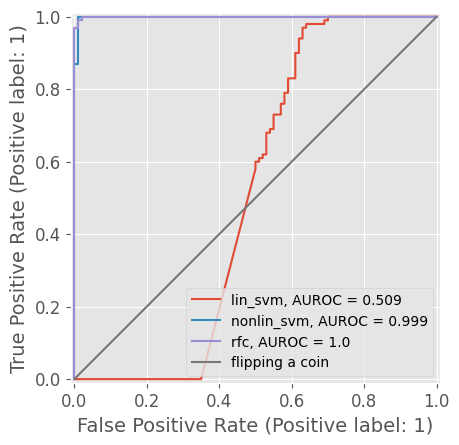

In [39]:
classifiers = [best_svm_lin, best_svm_nonlin, rfc]
roc_score = []
plt.figure()
ax = plt.gca()
for clf in classifiers:
    RocCurveDisplay.from_estimator(clf, x_test, y_test, ax=ax)
    roc_score.append(np.round(roc_auc_score(y_test, clf.predict_proba(x_test)[:,1]), decimals=3))
ax.plot(np.linspace(0,1,x_test.shape[0]),np.linspace(0,1,x_test.shape[0]))
plt.legend(('lin_svm, AUROC = '+str(roc_score[0]),'nonlin_svm, AUROC = '+str(roc_score[1]),'rfc, AUROC = '+str(roc_score[2]),'flipping a coin'))
plt.show()